---
## Notebook 1: EDA del Dataset de Noticias Falsas (WELFake)

**Nombre:** Zhang Tan Rubi

**Objetivo:** Aplicar todas las tecnicas de EDA que practicamos con el dataset pequeno al dataset real de noticias falsas **WELFake** (72,134 noticias).

### Instrucciones:
1. Descarga el dataset de Kaggle: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
2. Colocalo en `../data/WELFake_Dataset.csv`

### Entregables (completa el codigo en las celdas siguientes):

| # | Tarea | Descripcion |
|---|-------|-------------|
| 1 | Carga y exploracion | Verifica forma, columnas, tipos de datos, primeras filas |
| 2 | Distribucion de clases | Grafica de barras con conteos. Esta balanceado? |
| 3 | Longitudes de texto | Histogramas por clase para `title` y `text`. Calcula media, mediana, max |
| 4 | Valores nulos | Detecta, decide estrategia (eliminar o rellenar) y **documenta tu decision** |
| 5 | Duplicados | Detecta, elimina y verifica impacto en el balance de clases |
| 6 | Nubes de palabras | Una nube para noticias Reales y otra para Falsas |
| 7 | Pregunta | Que porcentaje de textos se truncarian con `max_len=200`? |

### Criterios de evaluacion:
- Codigo funcional sin errores
- Graficas claras con titulos y etiquetas
- Decisiones documentadas y justificadas en celdas markdown

## RETO 1.1 — Carga el dataset WELFake

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [ ]:
# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Carga del CSV
df = pd.read_csv('/content/drive/MyDrive/ModeladoPredictivo2026/data/WELFake_Dataset.csv')

# Eliminamos la columna de índice automático si es que existe
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Verificar forma, columnas, tipos de datos y primeras 5 filas del dataset
print(f'Forma del dataset: {df.shape}')
print(f'Número de filas: {df.shape[0]:,}')
print(f'Número de columnas: {df.shape[1]}')
print(f'\nColumnas y Tipos de datos:')
print(df.dtypes)
print(f'\nPrimeras 5 filas:')
df.head()

Forma del dataset: (72134, 3)
Número de filas: 72,134
Número de columnas: 3

Columnas y Tipos de datos:
title    object
text     object
label     int64
dtype: object

Primeras 5 filas:


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


El dataset tiene 72,134 noticias y 3 columnas: `title` (título), `text` (cuerpo del artículo) y `label` (0 = Fake, 1 = Real).

## RETO 1.2 — Distribucion de clases

Distribución de clases:
  Fake (label=0): 35,028  (48.6%)
  Real (label=1): 37,106  (51.4%)


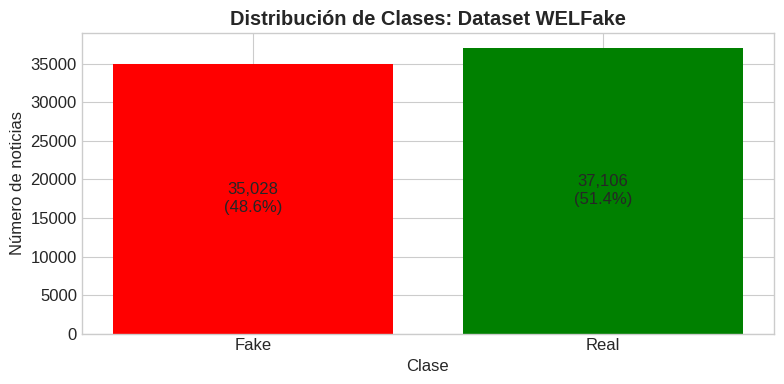

In [ ]:
# Mapeo de etiquetas
class_names = {0: 'Fake', 1: 'Real'}

class_counts = df['label'].value_counts().sort_index()

print('Distribución de clases:')
for label, count in class_counts.items():
    name = class_names[label]
    print(f'  {name} (label={label}): {count:,}  ({count / len(df) * 100:.1f}%)')

# Gráfica de barras
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['red', 'green']
bars = ax.bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values,
    color=colors)

for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() / 2,
        f'{count:,}\n({count / len(df) * 100:.1f}%)',
        ha='center', va='center'
    )

ax.set_xlabel('Clase')
ax.set_ylabel('Número de noticias')
ax.set_title('Distribución de Clases: Dataset WELFake', fontweight='bold')
plt.tight_layout()
plt.show()

El dataset WELFake está prácticamente balanceado (~50/50), lo cual es ideal para clasificación binaria, por lo que no se requieren técnicas de balanceo.

## RETO 1.3 — Distribucion de longitudes

In [ ]:
# Calcular longitudes (en numero de palabras)
df['title_len'] = df['title'].astype(str).apply(lambda x: len(x.split()))
df['text_len']  = df['text'].astype(str).apply(lambda x: len(x.split()))

# Estadisticas descriptivas
for col, label_col in [('title_len', 'TÍTULO'), ('text_len', 'TEXTO')]:
    print(f'=== Longitud del {label_col} (en palabras) ===')
    print(f'  Media   : {df[col].mean():.1f}')
    print(f'  Mediana : {df[col].median():.1f}')
    print(f'  Mínimo  : {df[col].min()}')
    print(f'  Máximo  : {df[col].max()}')

# Estadisticas por clase
print('=== Por clase ===')
for label, name in class_names.items():
    subset = df[df['label'] == label]
    print(f'  {name} → TÍTULO: media={subset["title_len"].mean():.1f}, med={subset["title_len"].median():.1f}, min={subset["title_len"].min()}, max={subset["title_len"].max()} | '
          f'TEXTO: media={subset["text_len"].mean():.1f}, med={subset["text_len"].median():.1f}, min={subset["text_len"].min()}, max={subset["text_len"].max()}')

=== Longitud del TÍTULO (en palabras) ===
  Media   : 12.2
  Mediana : 12.0
  Mínimo  : 1
  Máximo  : 72
=== Longitud del TEXTO (en palabras) ===
  Media   : 540.6
  Mediana : 398.0
  Mínimo  : 0
  Máximo  : 24234
=== Por clase ===
  Fake → TÍTULO: media=11.0, med=11.0, min=2, max=30 | TEXTO: media=577.6, med=427.0, min=0, max=14641
  Real → TÍTULO: media=13.3, med=13.0, min=1, max=72 | TEXTO: media=505.6, med=369.0, min=0, max=24234


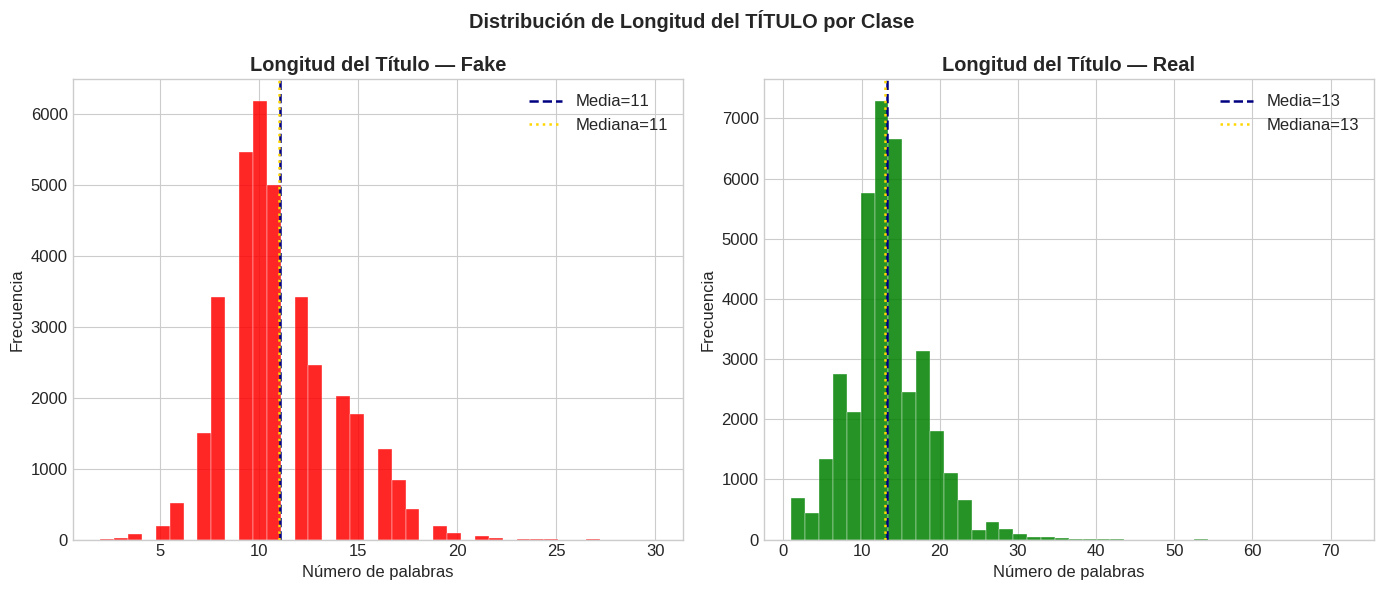

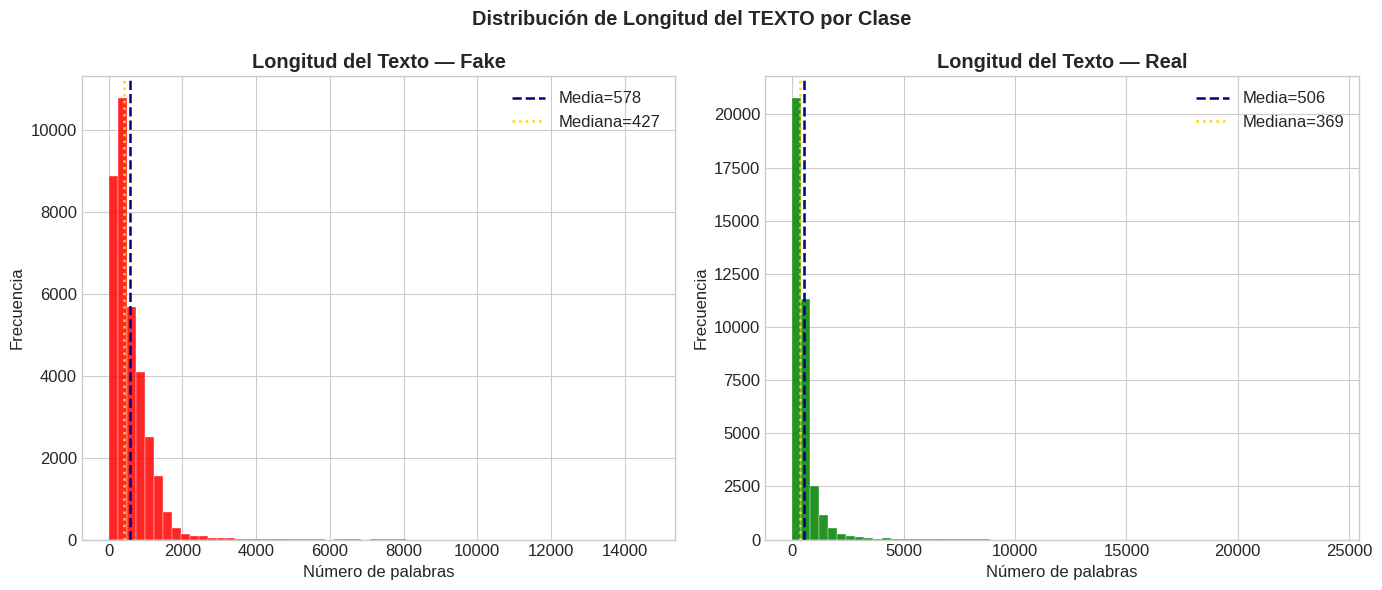

In [ ]:
# Histogramas: Longitud de título por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (label, name) in enumerate(class_names.items()):
    color = 'red' if label == 0 else 'green'
    subset = df[df['label'] == label]['title_len']
    axes[idx].hist(subset, bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[idx].axvline(subset.mean(), color='navy', linestyle='--', linewidth=1.8, label=f'Media={subset.mean():.0f}')
    axes[idx].axvline(subset.median(), color='gold', linestyle=':', linewidth=1.8, label=f'Mediana={subset.median():.0f}')
    axes[idx].set_title(f'Longitud del Título — {name}', fontweight='bold')
    axes[idx].set_xlabel('Número de palabras')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()

plt.suptitle('Distribución de Longitud del TÍTULO por Clase', fontweight='bold')
plt.tight_layout()
plt.show()

# Histogramas: Longitud de texto por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (label, name) in enumerate(class_names.items()):
    color = 'red' if label == 0 else 'green'
    subset = df[df['label'] == label]['text_len']
    axes[idx].hist(subset, bins=60, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[idx].axvline(subset.mean(), color='navy', linestyle='--', linewidth=1.8, label=f'Media={subset.mean():.0f}')
    axes[idx].axvline(subset.median(), color='gold', linestyle=':', linewidth=1.8, label=f'Mediana={subset.median():.0f}')
    axes[idx].set_title(f'Longitud del Texto — {name}', fontweight='bold')
    axes[idx].set_xlabel('Número de palabras')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()

plt.suptitle('Distribución de Longitud del TEXTO por Clase', fontweight='bold')
plt.tight_layout()
plt.show()

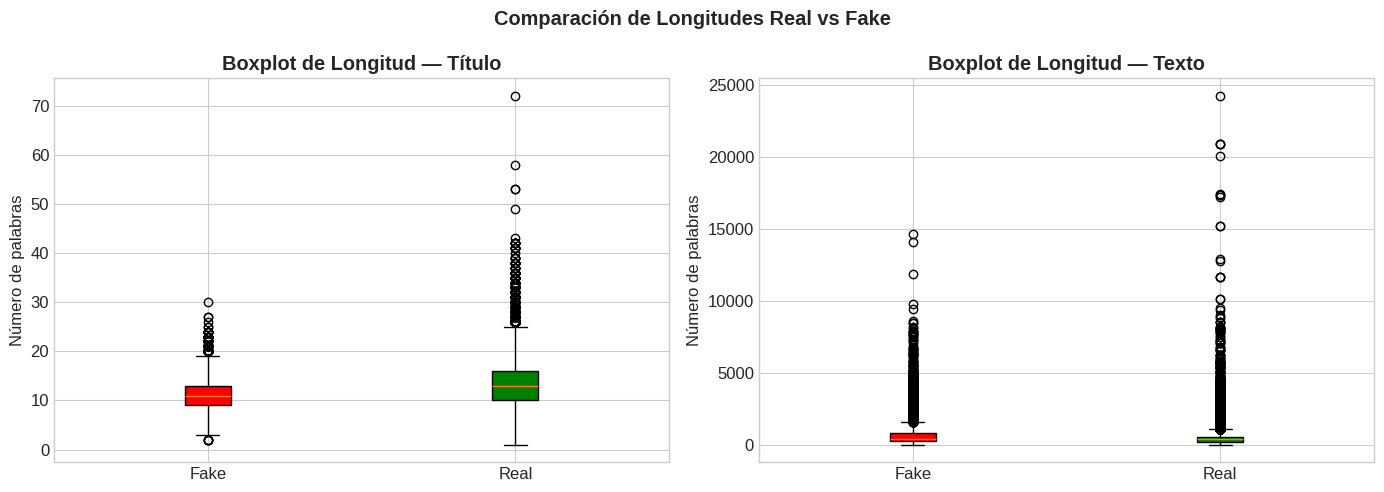

In [ ]:
# Boxplots comparativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, campo in zip(axes, ['title_len', 'text_len'], ['Título', 'Texto']):
    data_by_class = [df[df['label'] == l][col].values for l in class_names]
    bp = ax.boxplot(data_by_class, tick_labels=list(class_names.values()), patch_artist=True)
    bp['boxes'][0].set_facecolor('red')
    bp['boxes'][1].set_facecolor('green')
    ax.set_ylabel('Número de palabras')
    ax.set_title(f'Boxplot de Longitud — {campo}', fontweight='bold')

plt.suptitle('Comparación de Longitudes Real vs Fake', fontweight='bold')
plt.tight_layout()
plt.show()

- Los títulos de noticias **reales** son ligeramente más largos (media 13.3 palabras) que los de las falsas (media 11.0 palabras).
- Las noticias **reales** también tienen textos más largos (media 577.6 palabras) que las falsas (media 505.6 palabras), probablemente porque siguen estándares periodísticos (contexto, antecedentes y citas).
- Las noticias **falsas** tienen tanto títulos como textos más cortos, posiblemente porque están diseñadas para la viralización rápida y no requieren el respaldo de investigación periodística.
- La distribución del texto está sesgada a la derecha (pocos artículos muy extensos).

Por lo tanto, las noticias reales tienen títulos y textos más largos que las falsas.

## RETO 1.4 — Valores nulos

In [ ]:
# Deteccion de valores nulos
print('Valores nulos por columna:')
null_counts = df[['title', 'text', 'label']].isnull().sum()
print(null_counts)
print(f'\nTotal de filas con al menos un nulo: {df[['title', 'text', 'label']].isnull().any(axis=1).sum()}')
print(f'Porcentaje del dataset: {df[['title', 'text', 'label']].isnull().any(axis=1).sum() / len(df) * 100:.2f}%')

# Revisar si hay textos vacios (no NaN, pero sin contenido)
empty_title = (df['title'].fillna('').str.strip() == '').sum()
empty_text  = (df['text'].fillna('').str.strip() == '').sum()
print(f'\nTítulos vacíos (cadena vacia): {empty_title:}')
print(f'Textos  vacíos (cadena vacia): {empty_text:}')

Valores nulos por columna:
title    558
text      39
label      0
dtype: int64

Total de filas con al menos un nulo: 597
Porcentaje del dataset: 0.83%

Títulos vacíos (cadena vacia): 558
Textos  vacíos (cadena vacia): 783


In [ ]:
# Estrategia: rellenar nulos de 'title' con cadena vacía
# y eliminar filas con 'text' nulo o vacío

rows_before = len(df)

# Rellenar nulos en título con cadena vacia
df['title'] = df['title'].fillna('')

# Eliminar filas sin texto de cuerpo (no hay contenido clasificable)
df = df[df['text'].notna() & (df['text'].str.strip().str.len() > 0)].reset_index(drop=True)

rows_after = len(df)
print(f'Filas antes  : {rows_before:,}')
print(f'Filas después: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')
print(f'Nulos restantes: {df[["title", "text", "label"]].isnull().sum().sum()}')

Filas antes  : 72,134
Filas después: 71,351
Filas eliminadas: 783
Nulos restantes: 0


Estrategia:
- Los nulos en `title` se rellenaron con cadena vacía `''`. Debido a que el título puede estar ausente en algunos artículos, y el modelo puede clasificar de igual manera usando el cuerpo del texto.
- Las filas con `text` nulo o vacío se eliminaron porque sin el cuerpo de la noticia no hay contenido que el modelo pueda clasificar, además de que no aportan información. Fue una fracción muy pequeña del dataset.

## RETO 1.5 — Duplicados

In [ ]:
# Detección de duplicados
duplicates_mask = df.duplicated(subset=['title', 'text'], keep='first')
n_dup = duplicates_mask.sum()

print(f'Filas duplicadas encontradas: {n_dup:,} ({n_dup / len(df) * 100:.2f}%)')

if n_dup > 0:
    dup_idx = duplicates_mask[duplicates_mask].index[0]
    print(f'\nEjemplo de duplicado:')
    print(f'  Título : {str(df.loc[dup_idx, "title"])[:80]}...')
    print(f'  Texto  : {str(df.loc[dup_idx, "text"])[:120]}...')
    print(f'  Clase  : {class_names[df.loc[dup_idx, "label"]]}')

Filas duplicadas encontradas: 8,241 (11.55%)

Ejemplo de duplicado:
  Título : Just Weeks After Obama’s Executive Order on Catastrophic Space Weather Events, a...
  Texto  : By Melissa Dykes This has already been the craziest election in the history of the country, with the most overt corrupti...
  Clase  : Real


In [ ]:
# Eliminar duplicados
rows_before = len(df)
class_counts_before = df['label'].value_counts().sort_index()

df = df.drop_duplicates(subset=['title', 'text'], keep='first').reset_index(drop=True)
rows_after = len(df)
class_counts_after = df['label'].value_counts().sort_index()

print(f'Filas antes  : {rows_before:,}')
print(f'Filas después: {rows_after:,}')
print(f'Eliminadas   : {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before * 100:.2f}%)')

Filas antes  : 71,351
Filas después: 63,110
Eliminadas   : 8,241 (11.55%)


Distribución de clases tras eliminar duplicados:
  Fake: 34,790  (55.1%)
  Real: 28,320  (44.9%)


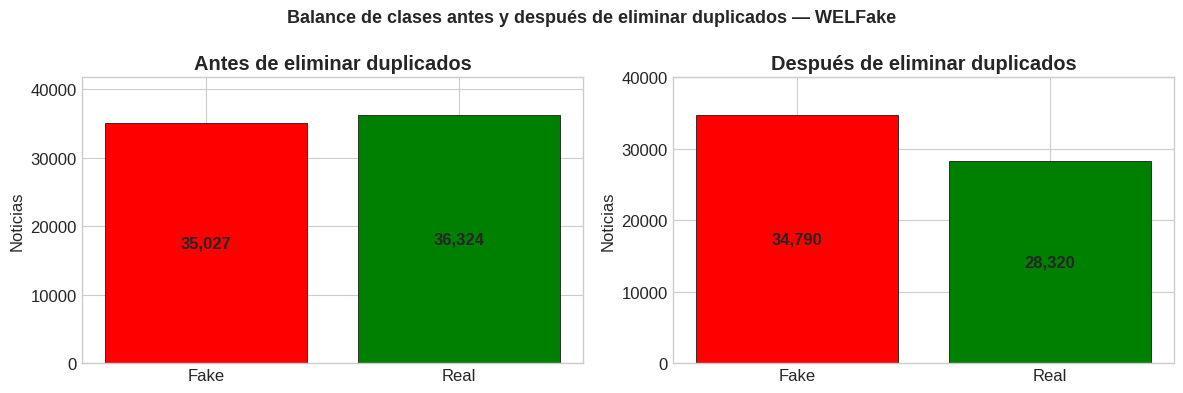

In [ ]:
# Verificar impacto en balance de clases
print('Distribución de clases tras eliminar duplicados:')
class_counts_post = df['label'].value_counts().sort_index()
for label, count in class_counts_post.items():
    name = class_names[label]
    print(f'  {name}: {count:,}  ({count / len(df) * 100:.1f}%)')

# Gráfica de barras
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, counts, title in zip(
    axes,
    [class_counts_before, class_counts_after],
    ['Antes de eliminar duplicados', 'Después de eliminar duplicados']
):
    colors_bar = ['red', 'green']
    ax.bar([class_names[i] for i in counts.index], counts.values,
           color=colors_bar, edgecolor='black', linewidth=0.5)
    for bar, count in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() / 2,
                f'{count:,}', ha='center', va='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Noticias')
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle('Balance de clases antes y después de eliminar duplicados — WELFake', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Se eliminaron los duplicados identificados, que son el 11.55% del dataset, conservando la primera aparición. Se eliminaron ya que podrían inflar las métricas si el mismo artículo aparece en train y test.

Se observa que las noticias **Reales** tenían proporcionalmente más duplicados, lo que cambió el balance de 51.4% Real / 48.6% Fake a 44.9% Real / 55.1% Fake tras la limpieza.

El balance de clases es de 55/45 después de la limpieza, el cual es un desbalance leve pero no se considera grave para afectar el entrenamiento de los modelos.

## RETO 1.6 — Nubes de palabras

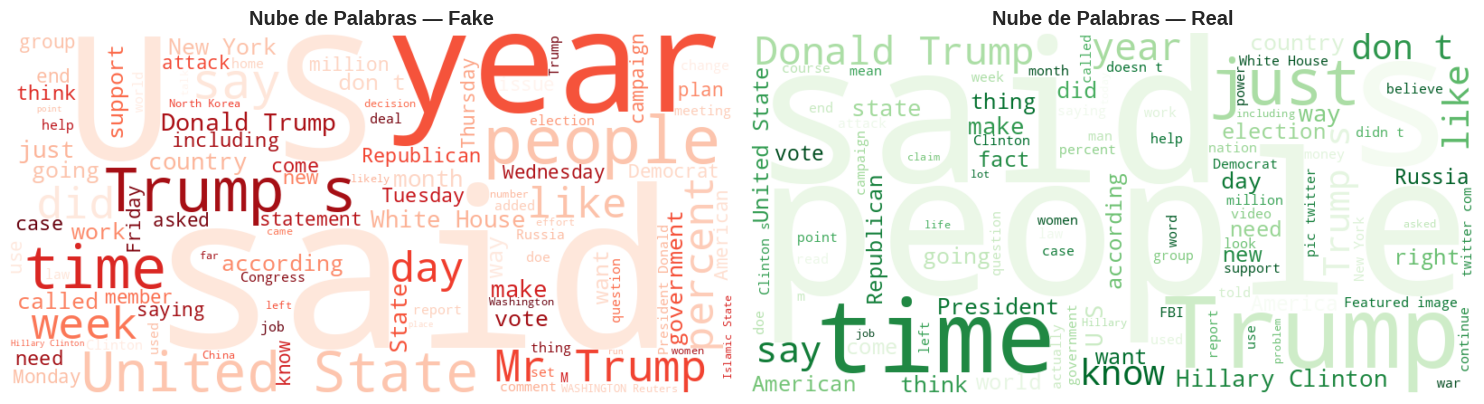

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (label, name) in enumerate(class_names.items()):
    text = ' '.join(df[df['label'] == label]['text'].astype(str).values)
    wordcloud = WordCloud(
        width=800, height=400,
        max_words=100,
        background_color='white',
        colormap='Reds' if label == 0 else 'Greens',
        stopwords=ENGLISH_STOP_WORDS,
        random_state=42
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras — {name}', fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

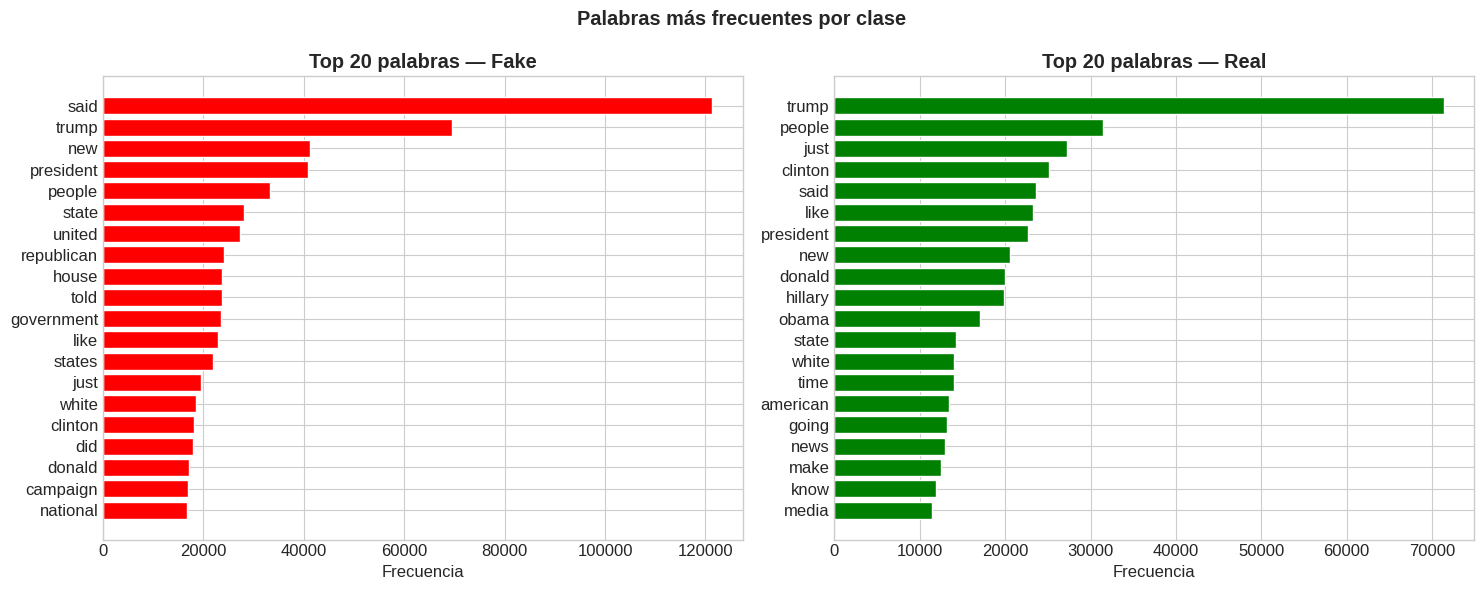

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, (label, name) in enumerate(class_names.items()):
    all_text = ' '.join(df[df['label'] == label]['text'].str.lower().fillna('').values)
    word_counts = Counter(all_text.split())

    filtered = {w: c for w, c in word_counts.items()
                if w not in ENGLISH_STOP_WORDS and len(w) > 2 and w.isalpha()}
    top_20 = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_20)

    color = 'red' if label == 0 else 'green'
    axes[idx].barh(range(len(words)), counts[::-1], color=color,
                   edgecolor='white')
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words[::-1])
    axes[idx].set_xlabel('Frecuencia')
    axes[idx].set_title(f'Top 20 palabras — {name}', fontweight='bold')

plt.suptitle('Palabras más frecuentes por clase', fontweight='bold')
plt.tight_layout()
plt.show()

Observaciones:
- Ambas clases comparten vocabulario político (*trump, people, said, state, president, clinton*), debido a que el dataset cubre noticias del mismo período y contexto político estadounidense.

- La diferencia más notable: las noticias **Falsas** tienen *said* como palabra dominante por ~120,000 ocurrencias, lo que es inesperado pero puede explicarse porque las noticias falsas frecuentemente citan o atribuyen declaraciones inventadas a figuras políticas. En las noticias **Reales**, *said* baja considerablemente en frecuencia relativa.

- Las noticias **Reales** tienen *trump* como palabra absolutamente dominante (~70,000 ocurrencias), seguido de *people*, *clinton*, *hillary*, *obama* y *donald*, con mayor concentración de nombres propios de figuras políticas específicas. También aparecen palabras como *just*, *like*, *know*, *going*, *media*, que sugieren un registro más informal y directo.

- Las noticias **Falsas** muestran un vocabulario más distribuido y periodístico: *said*, *president*, *new*, *state*, *republican*, *government*, *house*, lo que paradójicamente sugiere un estilo más formal en superficie.

- La palabra *news* aparece en el top 20 de **Real** pero no en el de **Fake**, posiblemente porque las noticias reales hacen referencia explícita a otras fuentes y medios como parte del contexto periodístico.

- *trump* aparece en ambas clases con alta frecuencia, por lo que sola no es un buen predictor de clase. Lo que diferenciará a las clases para el modelo será la combinación de palabras y su peso relativo, no palabras individuales aisladas.

## RETO 1.7 — Pregunta de reflexión

In [ ]:
# Porcentaje de textos con más de 200 palabras
pct_over_200 = (df['text_len'] > 200).mean() * 100
pct_under_200 = 100 - pct_over_200

print(f'Textos con MÁS de 200 palabras: {pct_over_200:.1f}%')
print(f'Textos con 200 palabras o menos: {pct_under_200:.1f}%')

# Percentiles para elegir max_len
print('\nPercentiles de longitud de texto:')
for p in [50, 75, 90, 95, 99]:
    val = np.percentile(df['text_len'], p)
    print(f'  Percentil {p}: {val:.0f} palabras')

Textos con MÁS de 200 palabras: 79.2%
Textos con 200 palabras o menos: 20.8%

Percentiles de longitud de texto:
  Percentil 50: 404 palabras
  Percentil 75: 677 palabras
  Percentil 90: 1106 palabras
  Percentil 95: 1404 palabras
  Percentil 99: 2679 palabras


In [ ]:
df.to_csv('WELFake_limpio.csv', index=False)
print(f'Dataset limpio guardado: {len(df):,} filas')

Dataset limpio guardado: 63,110 filas


---
## Preguntas de Reflexion sobre el Analisis Exploratorio de Datos

Responde las siguientes 10 preguntas en una celda markdown debajo de cada una. Tus respuestas deben estar fundamentadas en los resultados obtenidos durante el EDA.

**1.** ¿Por que es importante realizar un EDA antes de entrenar cualquier modelo de machine learning? ¿Que problemas podrian surgir si nos saltamos este paso?

**R1. El EDA es importante porque nos permite conocer y entender los datos que serán usados para entrenar el modelo. Principalmente, identificar valores nulos, duplicados u outliers, además de verificar la distribución de las clases, y detectar anomalías para tomar decisiones informadas (elegir max_len) para que el modelo no sea entrenado con datos que inflarían las métricas o que introducirían ruido.**


**2.** Al analizar la distribucion de clases, ¿encontraste que el dataset esta balanceado o desbalanceado? ¿Como afectaria un desbalance severo (por ejemplo 90/10) al entrenamiento de un clasificador? ¿Que tecnicas conoces para mitigarlo?

**R2. Antes de la limpieza estaba balanceado (Fake: 48.6%, Real: 51.4%). Después de eliminar duplicados quedó en 55.1% Fake, 44.9% Real, el cual es un desbalance leve. Si existe un desbalance severo, el modelo aprendería a predecir la clase mayoritaria e ignoraría la clase minoritaria, por lo que habría un sesgo en el modelo y darían métricas engañosas. Para mitigarlo, se puede hacer oversampling (SMOTE) de la clase minoritaria, undersampling de la clase mayoritaria.**


**3.** Observando las distribuciones de longitud del texto, ¿las noticias falsas tienden a ser mas largas o mas cortas que las reales? ¿Que hipotesis podrias formular sobre por que existe esa diferencia?

**R3. Las noticias falsas tienden a tener tanto títulos como textos más cortos que las reales. En cuanto al texto, la media de las falsas es 505.6 palabras vs 577.6 en reales. En el título, las falsas tienen media de 11.0 palabras vs 13.3 en reales. Mi hipótesis es que las noticias reales provienen de agencias periodísticas que siguen estándares editoriales que exigen contexto, antecedentes y citas, lo que naturalmente produce textos más largos y títulos más descriptivos. Las noticias falsas, al no estar respaldadas por investigación, no requieren ese desarrollo y están diseñadas para la viralización rápida con el menor esfuerzo posible.**


**4.** Si eligieras un `max_len=200` palabras para truncar los textos antes de alimentar una red neuronal, ¿que porcentaje de informacion se perderia? ¿Como decidiras el valor optimo de `max_len` considerando el trade-off entre informacion y costo computacional?

**R4. Con max_len de 200, se truncaría el 79.2% de los textos, lo que es una pérdida de información muy grande. Para elegir un valor óptimo, observamos los percentiles que se calcularon. El percentil 90 es de 1106 palabras, por lo que cubriría el 90% de los textos, pero tendría un costo computacional alto. Por lo tanto, podríamos elegir un percentil entre 60-65% que serían como 512 palabras para equilibrar el costo computacional y la información.**


**5.** ¿Que estrategia elegiste para manejar los valores nulos y por que? ¿En que escenarios seria mejor rellenar con un texto especial en lugar de eliminar las filas? ¿Y viceversa?

**R5. Para los 558 nulos en title se rellenaron con cadena vacía '', debido a que el título no es obligatorio para el modelo, ya que este puede clasificar usando el texto, si se eliminan se desperdician ejemplos para el entrenamiento. En el caso de los 783 nulos en text, se eliminaron ya que no hay material para poder hacer la clasificación, si se rellenaban con cadenas vacías podría confundir al modelo. Eliminar es preferible cuando el campo es imprescindible y los nulos representan una fracción pequeña del dataset, como ocurrió con `text`.**


**6.** El dataset WELFake tenia aproximadamente un 11.7% de duplicados. ¿Por que es critico eliminarlos antes de dividir en conjuntos de entrenamiento y prueba? ¿Que sucederia con las metricas de evaluacion si no lo hicieramos?

**R6. Si no eliminamos los duplicados antes de dividir en train y test, muchos artículos estarían en ambos conjuntos. Por lo tanto, si se evalúa el modelo en test, estaría siendo evaluado sobre ejemplos que ya vio durante el entrenamiento, lo que no mide generalización sino estaría memorizando los datos. Además, las métricas como Accuracy quedarían infladas y el resultado no sería representativo.**


**7.** ¿Que limitaciones tiene el EDA que realizamos? Menciona al menos dos aspectos del texto que NO exploramos y que podrian ser relevantes para la clasificacion (por ejemplo: estructura de oraciones, uso de signos de puntuacion, sentimiento, etc.).

**R7. Solo hicimos análisis de frecuencias, distribuciones y longitudes, por lo que no incluímos aspectos lingüístico como el tono o sentimiento. Por ejemplo, el uso de signos de puntuación (!!!, ???), la longitud promedio de las oraciones y el uso excesivo de mayúsculas.**


**8.** Reflexiona sobre el impacto social de las noticias falsas. ¿Por que es importante que como ingenieros desarrollemos herramientas para detectarlas? ¿Que responsabilidad etica conlleva construir un clasificador de este tipo? ¿Que sucede si el modelo comete errores (falsos positivos vs falsos negativos)?

**R8. Las noticias falsas causan desinformación en diferentes áreas dependiendo de la noticia, pueden generar violencia y hacer acusaciones falsas. Como ingenieros, tenemos la responsabilidad de hacer herramientas que ayuden y protejan a la sociedad. Si nuestro modelo comete errores, puede censurar información verdadera (falsos positivos) o puede permitir que las noticias falsas se difundan, causando desinformación (falsos negativos).**

**9.** Considerando todo lo aprendido en este EDA, ¿que caracteristicas (features) del texto crees que seran mas utiles para que un modelo distinga entre noticias reales y falsas? ¿Crees que el titulo, el cuerpo del texto, o ambos seran mas informativos? Justifica tu respuesta con base en los datos explorados.

**R9. Ambos son importantes por razones distintas. El texto contiene más contexto y detalles, por lo que es mayor volumen de datos para identificar patrones. Sin embargo, el título también es útil ya que los títulos fake suelen ser sensacionalistas y cortos, pero tienen muy poca cantidad de palabras para poder clasificar solamente con eso. Por lo tanto, ambos en conjunto serían más informativos para que el modelo aprenda los patrones de ambos.**